# Hafta 2 — Kök Bulma: İkiye Bölme, Newton, Sekant ve Sabit Nokta İterasyonu

> **Sıfırdan Sayısal Yöntemler** · Saf NumPy + Matplotlib

$f(x) = 0$ denklemini çözmek istiyoruz. Bu aldatıcı derecede basit problem, optimizasyonun (gradyanı sıfıra eşitle), denge hesabının ve örtük (implicit) zaman adımlamanın altında yatan iş gücüdür. Bu hafta dört çözücüyü sıfırdan inşa ediyoruz ve — kritik olarak — **yakınsama mertebelerini** analiz ediyoruz; bu büyüklük bize hatanın *ne kadar hızlı* küçüldüğünü söyler.

Bir yöntemin **mertebesi $p$** ise hatalar şunu sağlar:

$$ |e_{k+1}| \le C\,|e_k|^p. $$

Mertebe $1$ (doğrusal), adım başına sabit sayıda doğru basamak demektir; mertebe $2$ (karesel) ise her adımda doğru basamak sayısını *iki katına çıkarır*. Bu çarpıcı farkı canlı göreceğiz.

Konular:
1. **İkiye bölme** — garantili, sağlam, yavaş (doğrusal).
2. **Sabit nokta iterasyonu** ve büzülme koşulu $|g'(x^*)| < 1$.
3. **Newton yöntemi** — karesel, ama türev ve iyi bir başlangıç ister.
4. **Sekant yöntemi** — türevsiz, süperdoğrusal (mertebe $\varphi \approx 1.618$).
5. Başarısızlık türleri, çekim havzaları ve hibrit bir güvenlik önlemi.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. İkiye bölme — kurşun geçirmez taban çizgisi

$f$ sürekli ve $f(a)\,f(b) < 0$ ise, Ara Değer Teoremi $[a,b]$ aralığında bir kök garantiler. İkiye bölme aralığı tekrar tekrar yarılar, işaret değiştiren yarıyı tutar. $k$ adım sonra aralık genişliği $(b-a)/2^k$ olur; dolayısıyla $\varepsilon$ toleransına ulaşmak için

$$ k \ge \log_2\!\frac{b-a}{\varepsilon} $$

iterasyon gerekir — **tamamen öngörülebilir** ve geçerli bir aralık verildiğinde başarısız olamaz. Bedeli doğrusal yakınsamadır: adım başına bir bit doğruluk.


In [2]:
def ikiye_bolme(f, a, b, tol=1e-12, maxit=200):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("f(a) ve f(b) zıt işaretli olmalı")
    gecmis = []
    for k in range(maxit):
        m = 0.5 * (a + b)
        fm = f(m)
        gecmis.append(m)
        if abs(fm) == 0 or 0.5 * (b - a) < tol:
            break
        if fa * fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return m, np.array(gecmis)

f = lambda x: x**3 - x - 2          # 1.5214 civarında tek reel kök
kok, gecmis = ikiye_bolme(f, 1.0, 2.0)
print("kök:", kok, " iterasyon:", len(gecmis), " f(kök):", f(kok))


kök: 1.5213797068054191  iterasyon: 40  f(kök): 5.061284724661164e-12


## 2. Sabit nokta iterasyonu

$f(x)=0$ denklemini $x = g(x)$ biçiminde yeniden yazıp $x_{k+1} = g(x_k)$ ile iterasyon yapın. **Banach sabit nokta teoremine** göre, $g$ bir aralığı kendi içine eşliyor ve bir *büzülme* ise — $|g'(x)| \le L < 1$ — iterasyon tek sabit nokta $x^*$'a doğrusal $L$ hızıyla yakınsar:

$$ |x_{k+1} - x^*| \approx |g'(x^*)|\,|x_k - x^*|. $$

Aynı denklem birçok şekilde düzenlenebilir; **yalnızca bazıları yakınsar.** İşin püf noktası budur.


In [3]:
def sabit_nokta(g, x0, tol=1e-12, maxit=200):
    gecmis = [x0]
    x = x0
    for _ in range(maxit):
        xn = g(x)
        gecmis.append(xn)
        if abs(xn - x) < tol:
            break
        x = xn
    return xn, np.array(gecmis)

# x^3 - x - 2 = 0 çöz. İki yeniden düzenleme:
g_kotu = lambda x: x**3 - 2            # g'(x*) = 3 x*^2 ~ 6.9  -> ıraksar
g_iyi  = lambda x: np.cbrt(x + 2)      # g'(x*) küçük          -> yakınsar

_, h_iyi = sabit_nokta(g_iyi, 1.5)
print("iyi düzenleme şuna yakınsadı:", h_iyi[-1], " /", len(h_iyi)-1, "adımda")
xs = [1.5]
for _ in range(6):
    xs.append(g_kotu(xs[-1]))
print("kötü iteratlar (ıraksar):", xs)


iyi düzenleme şuna yakınsadı: 1.5213797068045323  / 14 adımda
kötü iteratlar (ıraksar): [1.5, 1.375, 0.599609375, -1.7844216004014015, -7.681884682517707, -455.31840313982127, -94394267.64680803]


Aynı kök, aynı başlangıç noktası — bir düzenleme yakınsar, diğeri patlar. Belirleyici etken tamamen $|g'(x^*)|$'dir. Bir sabit nokta şemasına güvenmeden önce daima türevi kontrol edin.

## 3. Newton yöntemi

Newton, $f$'yi mevcut iteratta doğrusallaştırır ve teğetin sıfırı kestiği yere adım atar:

$$ x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}. $$

Basit bir kök yakınında Taylor açılımı **karesel** hata yinelemesini verir:

$$ e_{k+1} \approx \frac{f''(x^*)}{2 f'(x^*)}\, e_k^2, $$

yani doğru basamak sayısı her iterasyonda kabaca *iki katına çıkar*. Dezavantajı: $f'$ gerekir, yeterince iyi bir başlangıç ister ve $f'(x^*) \neq 0$ olmalıdır.


In [4]:
def newton(f, df, x0, tol=1e-14, maxit=100):
    gecmis = [x0]
    x = x0
    for _ in range(maxit):
        fx = f(x)
        dfx = df(x)
        if dfx == 0:
            raise ZeroDivisionError("sıfır türev")
        xn = x - fx / dfx
        gecmis.append(xn)
        if abs(xn - x) < tol:
            break
        x = xn
    return xn, np.array(gecmis)

f  = lambda x: x**3 - x - 2
df = lambda x: 3*x**2 - 1
kok_n, gecmis_n = newton(f, df, 1.5)
print("Newton kökü:", kok_n, " iterasyon:", len(gecmis_n)-1)


Newton kökü: 1.5213797068045676  iterasyon: 4


### Karesel yakınsamayı izlemek

Mertebeyi *görmenin* en temiz yolu, her adımdaki hatayı yazdırmaktır. Karesel yakınsama altında hatanın üstel mertebesi satır başına kabaca iki katına çıkmalıdır.


In [5]:
xstar = kok_n
print(f"{'k':>3} {'x_k':>20} {'hata |x_k - x*|':>22}")
for k, x in enumerate(gecmis_n):
    print(f"{k:>3} {x:>20.16f} {abs(x - xstar):>22.3e}")


  k                  x_k        hata |x_k - x*|
  0   1.5000000000000000              2.138e-02
  1   1.5217391304347827              3.594e-04
  2   1.5213798059647863              9.916e-08
  3   1.5213797068045751              7.550e-15
  4   1.5213797068045676              0.000e+00


## 4. Sekant yöntemi

Türev mevcut değilse ya da pahalıysa, $f'(x_k)$'yi son iki iterattan geçen sonlu fark eğimiyle değiştirin:

$$ x_{k+1} = x_k - f(x_k)\,\frac{x_k - x_{k-1}}{f(x_k) - f(x_{k-1})}. $$

Yakınsama mertebesi **altın orandır** $\varphi = \frac{1+\sqrt5}{2} \approx 1.618$ — süperdoğrusal, adım başına Newton'dan yavaş ama türev gerektirmez ve iterasyon başına yalnızca bir fonksiyon değerlendirmesi yapar.


In [6]:
def sekant(f, x0, x1, tol=1e-14, maxit=100):
    gecmis = [x0, x1]
    f0, f1 = f(x0), f(x1)
    for _ in range(maxit):
        if f1 - f0 == 0:
            break
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        gecmis.append(x2)
        if abs(x2 - x1) < tol:
            break
        x0, f0, x1, f1 = x1, f1, x2, f(x2)
    return gecmis[-1], np.array(gecmis)

kok_s, gecmis_s = sekant(f, 1.0, 2.0)
print("Sekant kökü:", kok_s, " iterasyon:", len(gecmis_s)-2)


Sekant kökü: 1.5213797068045676  iterasyon: 8


## 5. Yakınsama hızı karşılaştırması

Dört yöntemin hata yörüngelerini logaritmik eksende çizelim. Her eğrinin *eğimi* mertebesini açığa çıkarır: ikiye bölme yumuşak bir doğru, Newton ise dik bir düşüş.


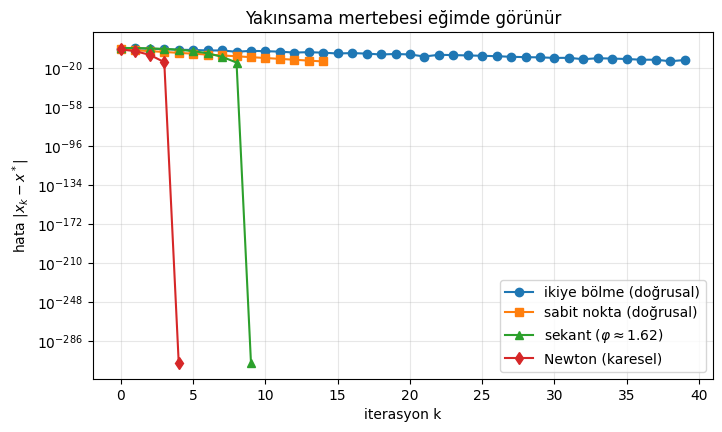

In [7]:
def hata_izi(gecmis, xstar):
    e = np.abs(np.array(gecmis, dtype=float) - xstar)
    e[e == 0] = np.finfo(float).tiny
    return e

xstar = kok_n
fig, ax = plt.subplots()
ax.semilogy(hata_izi(gecmis,   xstar), "o-", label="ikiye bölme (doğrusal)")
ax.semilogy(hata_izi(h_iyi,    xstar), "s-", label="sabit nokta (doğrusal)")
ax.semilogy(hata_izi(gecmis_s, xstar), "^-", label=r"sekant ($\varphi\approx1.62$)")
ax.semilogy(hata_izi(gecmis_n, xstar), "d-", label="Newton (karesel)")
ax.set_xlabel("iterasyon k")
ax.set_ylabel(r"hata $|x_k - x^*|$")
ax.set_title("Yakınsama mertebesi eğimde görünür")
ax.legend()
plt.show()


### Mertebeyi deneysel kestirmek

Mertebe $p$, ardışık üç hatadan sayısal olarak geri kazanılabilir:

$$ p \approx \frac{\ln(e_{k+1}/e_k)}{\ln(e_k/e_{k-1})}. $$


In [8]:
def mertebe_kestir(gecmis, xstar):
    e = hata_izi(gecmis, xstar)
    e = e[e > 1e-15]
    ps = []
    for k in range(1, len(e)-1):
        pay = np.log(e[k+1]/e[k])
        payda = np.log(e[k]/e[k-1])
        if payda != 0:
            ps.append(pay/payda)
    return ps

print("Newton kestirilen mertebeler:", np.round(mertebe_kestir(gecmis_n, xstar), 3))
print("Sekant kestirilen mertebeler:", np.round(mertebe_kestir(gecmis_s, xstar), 3))


Newton kestirilen mertebeler: [2.006 2.   ]
Sekant kestirilen mertebeler: [10.917  1.246  1.538  1.716  1.593  1.627  1.613]


Newton kestirimleri **2** civarında, sekant ise **1.6** civarında kümelenir — teori yalnızca veriden doğrulandı.

## 6. Başarısızlık türleri ve güvenli hibrit

Newton, türev küçükken ya da başlangıç kötüyken ıraksayabilir, döngüye girebilir veya fırlayabilir. Üretim kalitesinde bir çözücü, Newton'un hızını ikiye bölmenin güvenliğiyle birleştirir: Newton adımını **yalnızca mevcut aralığın içinde kalıyorsa** at, aksi halde ikiye bölmeye geri dön. Bu, Brent yönteminin altında yatan fikirdir.


In [9]:
def guvenli_newton(f, df, a, b, tol=1e-14, maxit=100):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("işaret değiştiren bir aralık gerekli")
    x = 0.5 * (a + b)
    for _ in range(maxit):
        fx = f(x)
        dfx = df(x)
        adim_uygun = dfx != 0
        if adim_uygun:
            xn = x - fx / dfx
            adim_uygun = a < xn < b          # Newton'u yalnızca aralıkta kalıyorsa kabul et
        if not adim_uygun:
            xn = 0.5 * (a + b)               # güvenli ikiye bölme yedeği
        fn = f(xn)
        if fa * fn < 0:
            b = xn
        else:
            a, fa = xn, fn
        if abs(xn - x) < tol:
            return xn
        x = xn
    return x

g  = lambda x: np.arctan(x)
dg = lambda x: 1.0 / (1 + x**2)
print("güvenli-Newton arctan kökü:", guvenli_newton(g, dg, -1.0, 5.0))


güvenli-Newton arctan kökü: 2.0


## Özet

| Yöntem | Mertebe | Türev gerekir mi? | Garantili mi? |
|---|---|---|---|
| İkiye bölme | 1 (doğrusal) | hayır | evet (aralıkla) |
| Sabit nokta | 1 (doğrusal, $|g'|<1$ ise) | hayır | koşullu |
| Sekant | $\approx 1.618$ | hayır | hayır |
| Newton | 2 (karesel) | evet | hayır |

- Aralık temelli yöntemler hızı **garantili** yakınsamayla takas eder.
- Açık yöntemler (Newton, sekant) hızlıdır ama iyi bir başlangıç olmadan başarısız olabilir.
- **Güvenli bir hibrit** ikisini de verir — mümkün olduğunda hızlı, her zaman güvenli.

---

## Alıştırmalar

**1. (Sıfırdan mertebe.)** $f(x)=\cos x - x$ için dört yöntemi de çalıştırıp deneysel mertebe kestirimini yeniden üretin. Newton$\to2$, sekant$\to1.618$ olduğunu doğrulayın.

**2. (Katlı kökler karesel yakınsamayı öldürür.)** Newton'u $f(x)=(x-1)^2$'ye uygulayın. Çift kökte yakınsamanın *doğrusala* indiğini ve değiştirilmiş Newton adımı $x_{k+1}=x_k - 2\,f/f'$'in karesel mertebeyi geri getirdiğini gösterin.

**3. (Çekim havzaları.)** Karmaşık başlangıç noktalarından oluşan bir ızgara üzerinde $f(z)=z^3-1$ için, her noktayı Newton'un yakınsadığı üç kökten birine göre renklendirin. Yalnızca NumPy ve `plt.imshow` kullanarak ünlü Newton fraktalını üretin.

**4. (Hangi düzenleme?)** $x^2 - 5 = 0$ için üç farklı sabit nokta biçimi $x=g(x)$ bulun. Her biri için $|g'(\sqrt5)|$ değerini hesaplayıp yakınsama/ıraksama öngörün, sonra sayısal doğrulayın.

**5. (Durdurma ölçütleri önemlidir.)** $f'$'nin minik olduğu kötü koşullu bir kök için $|x_{k+1}-x_k|$ ile $|f(x_k)|$ durdurma ölçütlerini karşılaştırın. Hangisi yanıltıcı ve kalıntı doğruluk hakkında neden yalan söyler?
